In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data_set=load_dataset('lukebarousse/data_jobs')
df = data_set['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
import ast
def clean_list(x):
    if pd.notna(x):
        return ast.literal_eval(x)
df['job_skills']=df['job_skills'].apply(clean_list)
df = df.drop_duplicates(subset=['job_title', 'job_location', 'job_via'])
df['job_id'] = df.index


c:\Users\Acer\miniconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_us=df[(df['job_country']=='United States')].dropna(subset=['salary_year_avg'])

In [4]:
job_titles=df_us['job_title_short'].value_counts().index[:6].tolist()


['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Analyst',
 'Senior Data Engineer']

In [5]:
df_us_top6=df_us[df['job_title_short'].isin(job_titles)]

C:\Users\Acer\AppData\Local\Temp\ipykernel_70008\3135057462.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_us_top6=df_us[df['job_title_short'].isin(job_titles)]


In [9]:
job_order=df_us_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index
job_order

Index(['Senior Data Scientist', 'Senior Data Engineer', 'Data Scientist',
       'Data Engineer', 'Senior Data Analyst', 'Data Analyst'],
      dtype='object', name='job_title_short')

Text(0, 0.5, '')

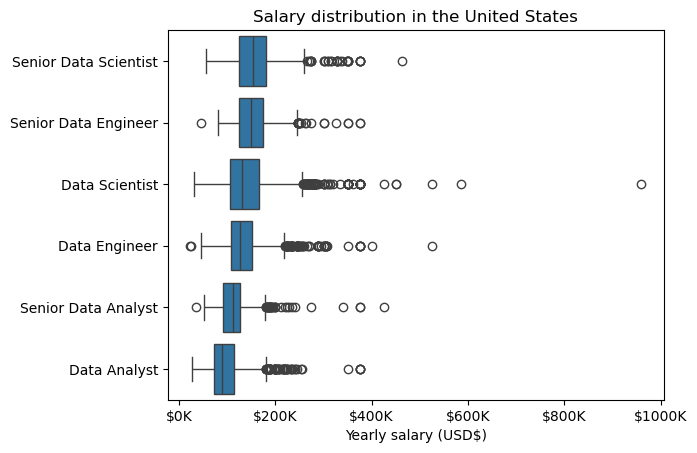

In [10]:
sns.boxplot(data=df_us_top6,x='salary_year_avg',y='job_title_short',order=job_order)
plt.title('Salary distribution in the United States')
plt.xlabel('Yearly salary (USD$)')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x ,pos: f'${int(x/1000)}K'))
ax.set_ylabel('')

In [11]:
df_da_us=df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')].copy()

In [12]:
df_da_us=df_da_us.dropna(subset=['salary_year_avg'])


In [ ]:
df_da_us=df_da_us.explode('job_skills')



In [17]:
df_da_us_top_pay=df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median',ascending=False)
df_da_us_top_pay=df_da_us_top_pay.head(10)

In [19]:
df_da_skills=df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_da_skills=df_da_skills.head(10).sort_values(by='median',ascending=False)
df_da_skills

,count,median
job_skills,,
python,1060,99957.5
tableau,1022,95000.0
sql,1857,93950.0
r,668,93027.0
sas,728,90245.0
power bi,608,90000.0
powerpoint,370,90000.0
sql server,223,90000.0
excel,1367,85000.0


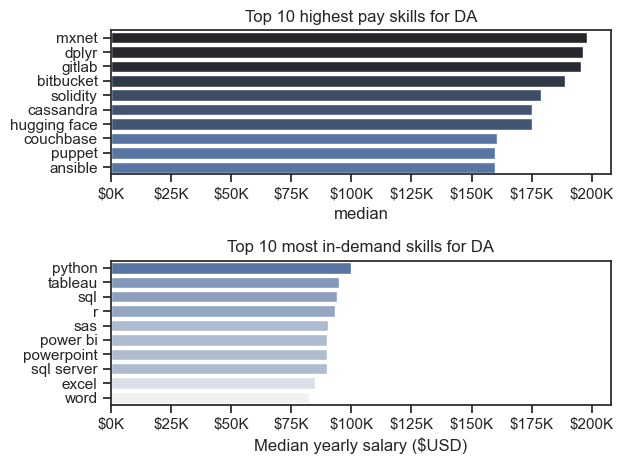

In [21]:


fig,ax=plt.subplots(2,1)
sns.set_theme(style='ticks')
sns.barplot(data=df_da_us_top_pay,x='median',y=df_da_us_top_pay.index,ax=ax[0],hue='median',palette='dark:b_r')
sns.barplot(data=df_da_skills,x='median',y=df_da_skills.index,ax=ax[1],hue='median',palette='light:b')
#df_DA_top_pay[::-1].plot(kind='barh',y='median',ax=ax[0])
#df_DA_skills[::-1].plot(kind='barh',y='median',ax=ax[1])
ax[1].set_xlim(ax[0].get_xlim())
ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].legend().remove()
ax[1].legend().remove()
ax[0].set_title('Top 10 highest pay skills for DA')
ax[1].set_title('Top 10 most in-demand skills for DA')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x ,pos: f'${int(x/1000)}K'))
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x ,pos: f'${int(x/1000)}K'))
ax[1].set_xlabel('Median yearly salary ($USD)')
fig.tight_layout()
